This notebook is reproduced from OpenCV Documentation, "Introduction to SIFT (Scale-Invariant Feature Transform)", section "SIFT in OpenCV".

Source: https://docs.opencv.org/4.x/da/df5/tutorial_py_sift_intro.html

# SIFT in OpenCV

So now let’s see SIFT functionalities available in OpenCV. Let’s start with keypoint detection and draw them. First we have to construct a SIFT object. We can pass different parameters to it which are optional and they are well explained in docs.

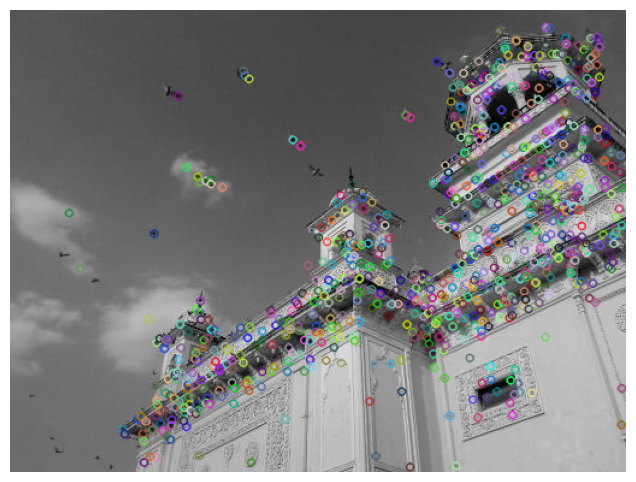

In [25]:
from matplotlib import pyplot as plt
import cv2

img = cv2.imread('data/home.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()
kp = sift.detect(gray, None)

img_kp = cv2.drawKeypoints(gray, kp, img)
cv2.imwrite('results/sift_keypoints.jpg', img_kp)

plt.figure(figsize=(10, 6)); plt.imshow(img_kp); plt.axis("off"); plt.show()

**sift.detect()** function finds the keypoint in the images. You can pass a mask if you want to search only a part of image. Each keypoint is a special structure which has many attributes like its (x,y) coordinates, size of the meaningful neighbourhood, angle which specifies its orientation, response that specifies strength of keypoints etc.

OpenCV also provides **cv2.drawKeyPoints()** function which draws the small circles on the locations of keypoints. If you pass a flag, **cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS** to it, it will draw a circle with size of keypoint and it will even show its orientation. See below example.

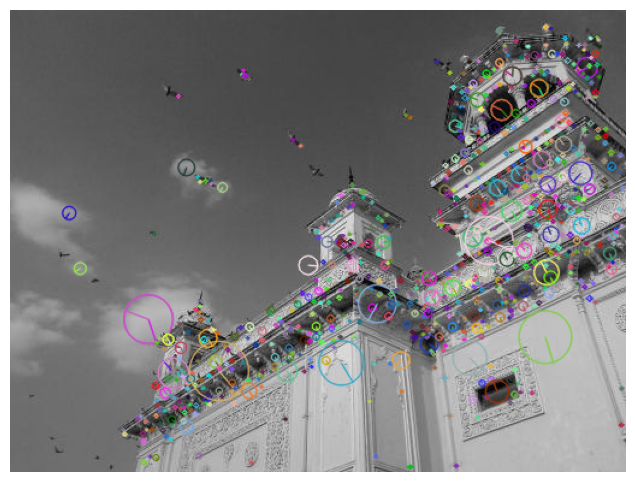

In [26]:
img_kp_rich = cv2.drawKeypoints(gray, kp, img, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
cv2.imwrite('results/sift_keypoints_rich.jpg', img_kp_rich)
plt.figure(figsize=(10, 6)); plt.imshow(img_kp_rich); plt.axis("off"); plt.show()


Now to calculate the descriptor, OpenCV provides two methods.

1. Since you already found keypoints, you can call **sift.compute()** which computes the descriptors from the keypoints we have found. Eg: kp,des = sift.compute(gray,kp)
2. If you didn’t find keypoints, directly find keypoints and descriptors in a single step with the function, **sift.detectAndCompute()**.

We will see the second method:

In [27]:
sift = cv2.SIFT_create()
kp, des = sift.detectAndCompute(gray, None)
des

array([[ 42.,   2.,   0., ...,  43.,   8.,   0.],
       [  5.,  23.,  42., ...,  84.,  11.,   0.],
       [  0.,   0.,   0., ...,   6.,   4.,   5.],
       ...,
       [145.,   1.,   0., ...,   0.,   0.,   0.],
       [  7.,   6.,   1., ...,  60.,  14.,   6.],
       [ 67.,   0.,   0., ...,   0.,   0.,  21.]],
      shape=(885, 128), dtype=float32)

Here kp will be a list of keypoints and des is a numpy array of shape \(Number\_of\_Keypoints * 128\).

So we got keypoints, descriptors etc. Now we want to see how to match keypoints in different images. That we will learn in coming chapters.